### Fine tuning a Mask R CNN model on the Penn-Fundan Database for pedestrian detection and segmentation.

### It contains 170 images with 375 instances of pedestrainas.

In [1]:
# Defining the data set

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!mkdir -p /content/drive/MyDrive/data

!wget https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip -P /content/drive/MyDrive/data
!unzip -qq /content/drive/MyDrive/data/PennFudanPed.zip -d /content/drive/MyDrive/data/

--2026-05-17 11:28:39--  https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip
Resolving www.cis.upenn.edu (www.cis.upenn.edu)... 158.130.69.163, 2607:f470:8:64:5ea5::d
Connecting to www.cis.upenn.edu (www.cis.upenn.edu)|158.130.69.163|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 53723336 (51M) [application/zip]
Saving to: ‘/content/drive/MyDrive/data/PennFudanPed.zip’

PennFudanPed.zip    100%[===================>]  51.23M  51.4MB/s    in 1.0s    

2026-05-17 11:28:40 (51.4 MB/s) - ‘/content/drive/MyDrive/data/PennFudanPed.zip’ saved [53723336/53723336]



In [2]:
!ls /content/drive/MyDrive/data/

PennFudanPed  PennFudanPed.zip


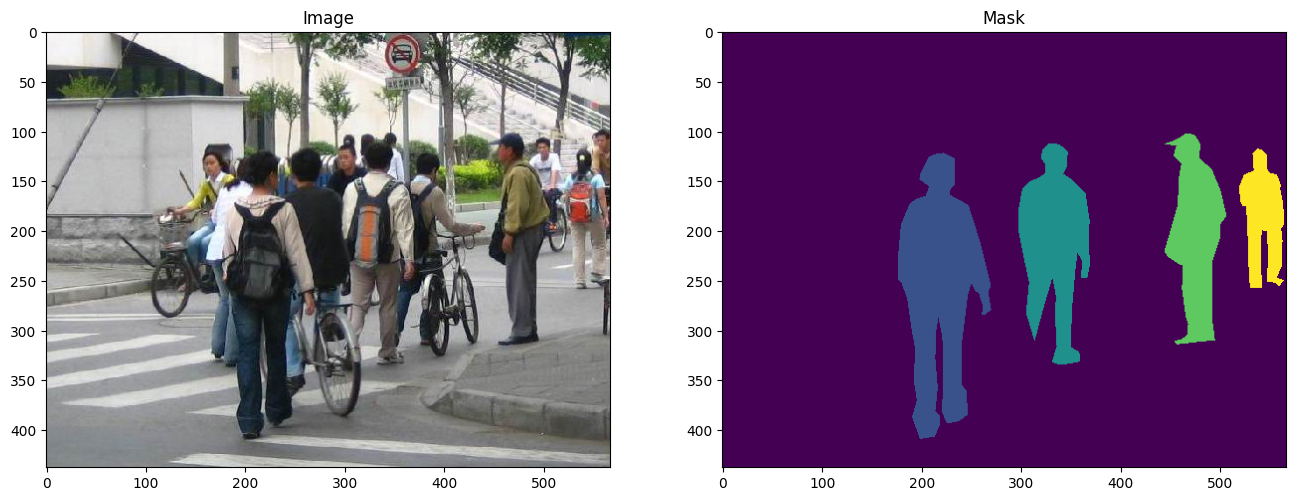

In [3]:
import matplotlib.pyplot as plt
from torchvision.io import read_image

image = read_image("/content/drive/MyDrive/data/PennFudanPed/PNGImages/FudanPed00046.png")
mask = read_image("/content/drive/MyDrive/data/PennFudanPed/PedMasks/FudanPed00046_mask.png")

plt.figure(figsize=(16,8))

plt.subplot(121)
plt.title("Image")
plt.imshow(image.permute(1,2,0))

plt.subplot(122)
plt.title("Mask")
plt.imshow(mask.permute(1,2,0))

plt.show()

So each image has a corresponding segmentation mask, where each color correspond to a different instance. Let’s write a torch.utils.data.Dataset class for this dataset. In the code below, we are wrapping images, bounding boxes and masks into torchvision.tv_tensors.TVTensor classes so that we will be able to apply torchvision built-in transformations (new Transforms API) for the given object detection and segmentation task. Namely, image tensors will be wrapped by torchvision.tv_tensors.Image, bounding boxes into torchvision.tv_tensors.BoundingBoxes and masks into torchvision.tv_tensors.Mask. As torchvision.tv_tensors.TVTensor are torch.Tensor subclasses, wrapped objects are also tensors and inherit the plain torch.Tensor API.

In [4]:
import os
import torch


from torchvision.io import read_image
from torchvision.ops.boxes import masks_to_boxes
from torchvision import tv_tensors
from torchvision.transforms.v2 import functional as F

In [5]:
class PennFudanDataset(torch.utils.data.Dataset):
    def __init__(self, root, transforms):
        self.root = root
        self.transforms = transforms
        # load all image files, sorting them to
        # ensure that they are aligned
        self.imgs = list(sorted(os.listdir(os.path.join(root, "PNGImages"))))
        self.masks = list(sorted(os.listdir(os.path.join(root, "PedMasks"))))

    def __getitem__(self, idx):
        # load images and masks
        img_path = os.path.join(self.root, "PNGImages", self.imgs[idx])
        mask_path = os.path.join(self.root, "PedMasks", self.masks[idx])
        img = read_image(img_path)
        mask = read_image(mask_path)
        # instances are encoded as different colors
        obj_ids = torch.unique(mask)
        # first id is the background, so remove it
        obj_ids = obj_ids[1:]
        num_objs = len(obj_ids)

        # split the color-encoded mask into a set
        # of binary masks
        masks = (mask == obj_ids[:, None, None]).to(dtype=torch.uint8)

        # get bounding box coordinates for each mask
        boxes = masks_to_boxes(masks)

        # there is only one class
        labels = torch.ones((num_objs,), dtype=torch.int64)

        image_id = idx
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        # suppose all instances are not crowd
        iscrowd = torch.zeros((num_objs,), dtype=torch.int64)

        # Wrap sample and targets into torchvision tv_tensors:
        img = tv_tensors.Image(img)

        target = {}
        target["boxes"] = tv_tensors.BoundingBoxes(boxes, format="XYXY", canvas_size=F.get_size(img))
        target["masks"] = tv_tensors.Mask(masks)
        target["labels"] = labels
        target["image_id"] = image_id
        target["area"] = area
        target["iscrowd"] = iscrowd

        if self.transforms is not None:
            img, target = self.transforms(img, target)

        return img, target

    def __len__(self):
        return len(self.imgs)

###  Fine tuning from a pretrined model

In [6]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

#load  the pretrained network , traine don COCO dataset
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights = "DEFAULT")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 182MB/s]


In [7]:
print(model)

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [6]:
for name, module in model.named_children():
    print(name)

transform
backbone
rpn
roi_heads


In [7]:
for name, module in model.named_modules():
    print(name)


transform
backbone
backbone.body
backbone.body.conv1
backbone.body.bn1
backbone.body.relu
backbone.body.maxpool
backbone.body.layer1
backbone.body.layer1.0
backbone.body.layer1.0.conv1
backbone.body.layer1.0.bn1
backbone.body.layer1.0.conv2
backbone.body.layer1.0.bn2
backbone.body.layer1.0.conv3
backbone.body.layer1.0.bn3
backbone.body.layer1.0.relu
backbone.body.layer1.0.downsample
backbone.body.layer1.0.downsample.0
backbone.body.layer1.0.downsample.1
backbone.body.layer1.1
backbone.body.layer1.1.conv1
backbone.body.layer1.1.bn1
backbone.body.layer1.1.conv2
backbone.body.layer1.1.bn2
backbone.body.layer1.1.conv3
backbone.body.layer1.1.bn3
backbone.body.layer1.1.relu
backbone.body.layer1.2
backbone.body.layer1.2.conv1
backbone.body.layer1.2.bn1
backbone.body.layer1.2.conv2
backbone.body.layer1.2.bn2
backbone.body.layer1.2.conv3
backbone.body.layer1.2.bn3
backbone.body.layer1.2.relu
backbone.body.layer2
backbone.body.layer2.0
backbone.body.layer2.0.conv1
backbone.body.layer2.0.bn1
bac

In [8]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

#load  the pretrained network , traine don COCO dataset
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights = "DEFAULT")

#replace the classifier with a new one
# where the number of classes is user-defined

num_classes = 2

#get number of input features for the classifier

in_features = model.roi_heads.box_predictor.cls_score.in_features

#replace the pretrained head with a new one
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

## Modifying the model to add a different backbone

Backbone:
"What features exist?"

FPN:
"Handle multiple object scales"

RPN:
"Where could objects be?"

ROI Heads:
"What object is this and where exactly?"

In [9]:
import torchvision
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator

# load pretrained model for classification and return only the features
backbone = torchvision.models.mobilenet_v2(weights = "DEFAULT").features

#FasterRCNN needs to know the number of output channels in a backbone.
#For mobilenet_v2, it is 1280, so we need to add it here
backbone.out_channels = 1280

# Let's make the RPN generate 5x3 anchors per spatial location
# with 5 different sizes and 3 different aspect ratios.
# We have a Tuple[Tuple[int]] beacuse each feature map could
# potentially have different sizes and espect ratios
anchor_generator = AnchorGenerator(
    sizes=((32, 64, 128, 256, 512),),
    aspect_ratios=((0.5, 1.0, 2.0),)
)

'''
the above part says:

location +

32,tall
32,square
32,wide

64,tall
64,square
64,wide

...

512,tall
512,square
512,wide
'''

# let';s define what are the feature maps that we will use to perform
# The region of interest cropping, as well as, the size of the crop after rescaling.
# If your backbone returns a Tensor, featmap_names is expected to be [0]
# More generally, the backbone should return an ''OrderedDict[Tensor]''
# and in ''featmap_names'' you can choose which feature maps to use.

roi_pooler = torchvision.ops.MultiScaleRoIAlign(
    featmap_names=['0'],
    output_size=7,
    sampling_ratio=2
)
# put the peieces together inside a Faster RCNN model
model = FasterRCNN(
    backbone,
    num_classes = 2,
    rpn_anchor_generator = anchor_generator,
    box_roi_pool = roi_pooler
)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 104MB/s] 


## Object detection and instance segmentation model for PennFundan Dataset

In our case we want to finetune from a pre-trained model, given that our dataset is very smal;l, so we will be following approach number 1

Here we want to also compute the instance segmentration masks, so we will be using Mask-RCNN

In [18]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

def get_model_instance_segmentation(num_classes):
    # load an instance segmentation model pre-trained on COCO
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights = "DEFAULT")

    # get number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features

    # replace the pre-trained head with a new one
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    # now get the number of input features for the mask classifier
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256

    # and replace the mask predictor with a new one
    model.roi_heads.mask_predictor = MaskRCNNPredictor(
        in_features_mask,
        hidden_layer,
        num_classes
    )

    return model

### That's it, this will make 'model' be ready to be trained and evaluated on your custom dataset

## Putting everything together!!!!

In [11]:
os.system("wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/engine.py")
os.system("wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/utils.py")
os.system("wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/coco_utils.py")
os.system("wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/coco_eval.py")
os.system("wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/transforms.py")

0

In [12]:
import torchvision
print(torchvision.__version__)

0.25.0+cu128


Lets write som emore helper functions

In [13]:
from torchvision.transforms import v2 as T

def get_transform(train):
    transforms = []
    if train:
        transforms.append(T.RandomHorizontalFlip(0.5))
    transforms.append(T.ToDtype(torch.float, scale=True))
    transforms.append(T.ToPureTensor())
    return T.Compose(transforms)

Testing the forward() method (Optional)

In [14]:
import utils

model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights = "DEFAULT")
dataset = PennFudanDataset('/content/drive/MyDrive/data/PennFudanPed', get_transform(train=True))
data_loader = torch.utils.data.DataLoader(
    dataset,
    batch_size = 2,
    shuffle = True,
    collate_fn = utils.collate_fn
)

# FOr training
images, targets = next(iter(data_loader))
images = list(image for image in images)
targets = [{k: v for k, v in t.items()} for t in targets]
output = model(images, targets) # Returns losses and detetcion
print(output)

# For inference
model.eval()
x = [torch.rand(3, 300, 400), torch.rand(3, 500, 400)]
predictions = model(x)
print(predictions[0])

{'loss_classifier': tensor(0.0846, grad_fn=<NllLossBackward0>), 'loss_box_reg': tensor(0.0445, grad_fn=<DivBackward0>), 'loss_objectness': tensor(0.0073, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>), 'loss_rpn_box_reg': tensor(0.0024, grad_fn=<DivBackward0>)}
{'boxes': tensor([], size=(0, 4), grad_fn=<StackBackward0>), 'labels': tensor([], dtype=torch.int64), 'scores': tensor([], grad_fn=<IndexBackward0>)}


### We want to be able to train our model on an accelerator such as CUDA, MPS, MTIA, XPU. Let's now write the main function which performs the training and the validation

In [21]:
from engine import train_one_epoch, evaluate

# train on the accelerator or on the CPU, if an accelerator is not available
device = torch.accelerator.current_accelerator() if torch.accelerator.is_available() else torch.device('cpu')

# our dataset has two classes only - background and person
num_classes = 2
# use our dataset and defined transformations
dataset = PennFudanDataset('/content/drive/MyDrive/data/PennFudanPed', get_transform(train=True))
dataset_test = PennFudanDataset('/content/drive/MyDrive/data/PennFudanPed', get_transform(train=False))

# split the dataset in train and test set
indices = torch.randperm(len(dataset)).tolist()
dataset = torch.utils.data.Subset(dataset, indices[:-50])
dataset_test = torch.utils.data.Subset(dataset_test, indices[-50:])

# define training and validation data loaders
data_loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=utils.collate_fn
)

data_loader_test = torch.utils.data.DataLoader(
    dataset_test,
    batch_size=1,
    shuffle=False,
    collate_fn=utils.collate_fn
)

# get the model using our helper function
model = get_model_instance_segmentation(num_classes)

# move model to the right device
model.to(device)

# construct an optimizer
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(
    params,
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005
)

# and a learning rate scheduler
lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=3,
    gamma=0.1
)

# let's train it just for 2 epochs
num_epochs = 2

for epoch in range(num_epochs):
    # train for one epoch, printing every 10 iterations
    train_one_epoch(model, optimizer, data_loader, device, epoch, print_freq=10)
    # update the learning rate
    lr_scheduler.step()
    # evaluate on the test dataset
    evaluate(model, data_loader_test, device=device)
print("Done!")

/content/engine.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=scaler is not None):


Epoch: [0]  [ 0/60]  eta: 0:04:01  lr: 0.000090  loss: 4.4440 (4.4440)  loss_classifier: 0.4279 (0.4279)  loss_box_reg: 0.2248 (0.2248)  loss_mask: 3.7739 (3.7739)  loss_objectness: 0.0154 (0.0154)  loss_rpn_box_reg: 0.0020 (0.0020)  time: 4.0278  data: 1.6342  max mem: 2255
Epoch: [0]  [10/60]  eta: 0:01:24  lr: 0.000936  loss: 1.5353 (2.3676)  loss_classifier: 0.3052 (0.3141)  loss_box_reg: 0.2699 (0.2657)  loss_mask: 0.8392 (1.7623)  loss_objectness: 0.0154 (0.0204)  loss_rpn_box_reg: 0.0029 (0.0051)  time: 1.6974  data: 0.9913  max mem: 3040
Epoch: [0]  [20/60]  eta: 0:01:03  lr: 0.001783  loss: 0.8754 (1.5775)  loss_classifier: 0.1673 (0.2241)  loss_box_reg: 0.2354 (0.2506)  loss_mask: 0.4643 (1.0733)  loss_objectness: 0.0184 (0.0221)  loss_rpn_box_reg: 0.0054 (0.0074)  time: 1.4609  data: 0.9183  max mem: 3134
Epoch: [0]  [30/60]  eta: 0:00:47  lr: 0.002629  loss: 0.6273 (1.2623)  loss_classifier: 0.0983 (0.1811)  loss_box_reg: 0.2099 (0.2427)  loss_mask: 0.2843 (0.8109)  loss_ob

### let's see the predictions

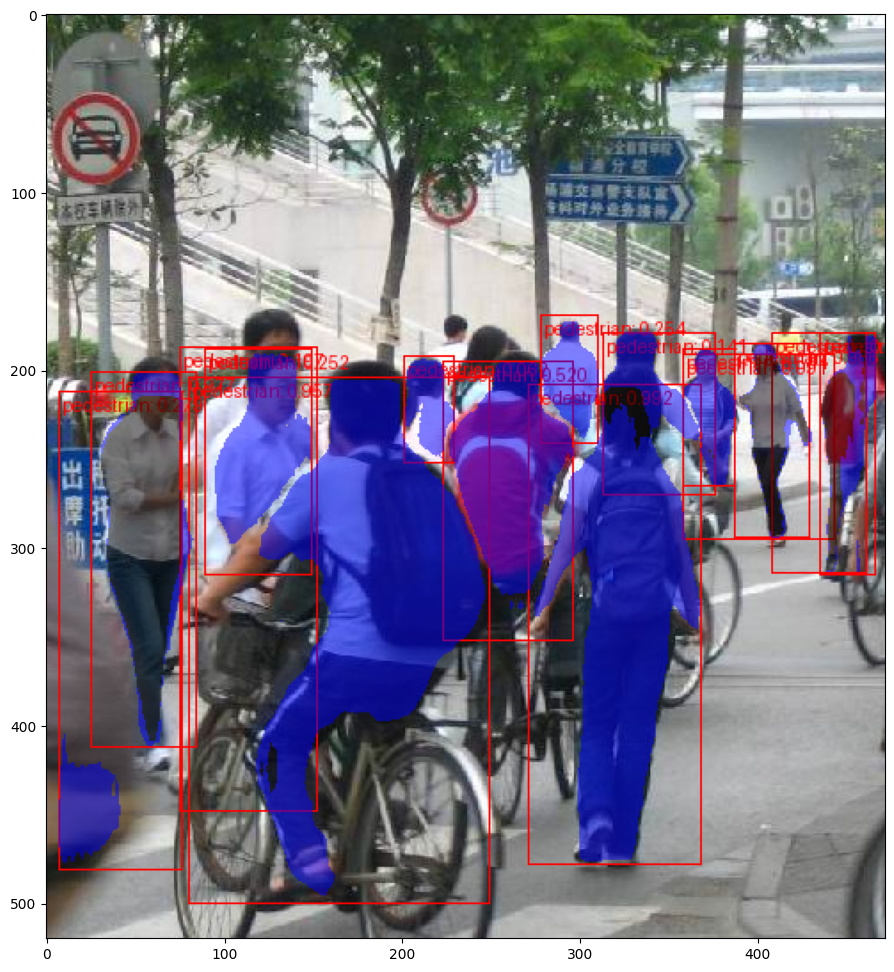

In [23]:
import matplotlib.pyplot as plt

from torchvision.utils import draw_bounding_boxes, draw_segmentation_masks

image = read_image("/content/drive/MyDrive/data/PennFudanPed/PNGImages/FudanPed00047.png")
eval_transform = get_transform(train=False)

model.eval()
with torch.no_grad():
    x = eval_transform(image)

    # convert RGBA to RGB
    x = x[:3, ...].to(device)
    predictions = model([x, ])
    pred = predictions[0]

image = (255.0 * (image - image.min()) / (image.max() - image.min())).to(torch.uint8)
image = image[:3, ...]
pred_labels = [f"pedestrian: {score:.3f}" for label, score in zip(pred["labels"], pred["scores"])]
pred_boxes = pred["boxes"].long()
output_image = draw_bounding_boxes(image, pred_boxes, pred_labels, colors="red")

masks = (pred["masks"] > 0.7).squeeze(1)
output_image = draw_segmentation_masks(output_image, masks, alpha=0.5, colors="blue")


plt.figure(figsize=(12, 12))
plt.imshow(output_image.permute(1, 2, 0))
